# Setting up the notebook

In [1]:
#%matplotlib notebook
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
# for loading of custom modules
import sys
from time import sleep
# mac_home_module_path = '/Users/martinploschner/OneDrive - The University of Queensland/Coding/python_scripts/MODULES/'
# sys.path.insert(1, mac_home_module_path)

win_home_module_path = r'C:\\LAB\\Coding\\Python\\MODULES'
sys.path.insert(1, win_home_module_path)


# for Thorlabs powermeter
import pyvisa as pv
from systemutils import tcolor # controls terminal text colors
from IPython.display import clear_output # allows inline terminal updating
import Thorlabs_PM100USB as TLpm

# for SLM 
%gui qt5
import fullscreenqt
import time

# Init power meters

In [3]:
unit = ["dBm","W"][0]
wavelength = 1300
rm = pv.ResourceManager()
resource_list = rm.list_resources()
print(resource_list)

#pw1 = rm.open_resource(resource_list[0])#Connected to Ref.arm
#pw2 = rm.open_resource(resource_list[1])

('USB0::0x1313::0x8072::P2004008::INSTR', 'USB0::0x1313::0x8072::P2004984::INSTR', 'USB0::0x1313::0x8072::P2004007::INSTR', 'ASRL1::INSTR', 'ASRL4::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL8::INSTR', 'ASRL10::INSTR')


In [4]:
PM1 = TLpm.ThorlabsPM100USB(rm,resource_list[0],unit=unit,wavelength=wavelength,avg_count=10)
PM2 = TLpm.ThorlabsPM100USB(rm,resource_list[1],unit=unit,wavelength=wavelength,avg_count=10)
PM_ref = TLpm.ThorlabsPM100USB(rm,resource_list[2],unit=unit,wavelength=wavelength,avg_count=10)


Thorlabs,PM100USB,P2004008,1.4.0

Device status: 

Module ID: Thorlabs,PM100USB,P2004008,1.4.0

Sensor ID: S154C,14111440,14-Nov-2014,1,18,289

Wavelength: 1300.00 nm
Average count: 10
Unit: DBM

Thorlabs,PM100USB,P2004984,1.4.0

Device status: 

Module ID: Thorlabs,PM100USB,P2004984,1.4.0

Sensor ID: S155C,14100230,02-Oct-2014,1,18,289

Wavelength: 1300.00 nm
Average count: 10
Unit: DBM

Thorlabs,PM100USB,P2004007,1.4.0

Device status: 

Module ID: Thorlabs,PM100USB,P2004007,1.4.0

Sensor ID: S154C,14111241,12-Nov-2014,1,18,289

Wavelength: 1300.00 nm
Average count: 10
Unit: DBM



In [25]:
PM_ref.close()
PM2.close()
PM1.close()

In [26]:
rm.close()

In [205]:
print( PM1.read_power_single_threaded() )
print( PM2.read_power_single_threaded() )

-29.8969822
-41.3822517


In [12]:
screen_data[:,0:1920//2,0] = 0
window.update()

# Open and initialise the fullscreen window

In [5]:
window, app = fullscreenqt.startfullscreen(screen = 2)
screen_data = window.getBuffer()

1152 1920


In [87]:
#screen_data[:,1920//2:-1,0] = 0 # [y,x,RGB channel]
screen_data[:,0:1920//2,0] = 255 # [y,x,RGB channel]
window.update()

In [24]:
window.close()

True

# Measure SLM gamma curve MultiThreading  (with reference)

In [54]:
from IPython.display import clear_output
from systemutils import tcolor
import time
from threading import Thread

#Power Meter Variables
power_offset = 30
powers = [{}]*2 #We store the read powers in the power meter read thread here so we can access from everwhere (GLOBAL VARIABLE)

#Terminate the threads flags
flag = True
run_flag = [1]
run_flag[0] = flag

#Gamma curve variables
ref_power_0 = PM1.read_power_single_threaded() # initial power in the reference arm
gray_level = 0
side = ['left','right'][0]
scan = arange(0,256,1)

output_data = {'measured_power':[], 'level':[]}
measured_power = []
level = []

cnt = zeros(2) #Check number of measurements in both (ref and signal threads)

def read_ref(buffer, flag):
    while flag[0]:
        PM1.read_power_multi_threaded(buffer)
        cnt[0] = cnt[0] + 1 
        
def read_signal(buffer, flag):
    while run_flag[0]:
        PM2.read_power_multi_threaded(buffer)
        cnt[1] = cnt[1] + 1
        
def GammaCurveRoutine():
    
    for gray_level in scan:
    
        if side is 'right':
            screen_data[:,1920//2:-1,0] = gray_level # right-side piston
        elif side is 'left':
            screen_data[:,0:1920//2,0] = gray_level # left-side piston

        window.update()
        time.sleep(0.3)  

        clear_output(wait = True)
        
        #Read powers
        ref_power = powers[0]
        power = powers[1]
        fluctuation =  ref_power - ref_power_0
        
        #Print Stats
        print(tcolor.BLUE + '(Reference power meter)\n' + f"{(ref_power):0.4f} " + unit +"\n\n" \
              + 'Signal power meter' + '\n' + f"{(power):0.4f} " + unit + "\n\n" \
              + 'Reference change: ' + f"{(fluctuation):0.4f} " + unit + "\n" \
              + "Measured power (refrence adjusted): " + f"{(power - fluctuation + power_offset):0.4f} " + unit + tcolor.END)
        
        
        output_data['measured_power'].append( power - fluctuation + power_offset)
        output_data['level'].append(gray_level) 

(Reference power meter)
-28.9154 dBm

Signal power meter
-43.3817 dBm

Reference change: 0.9614 dBm
Measured power (refrence adjusted): -14.3431 dBm
Gamma Curve Done!
Extintion Ratio =  38.1903133  dB


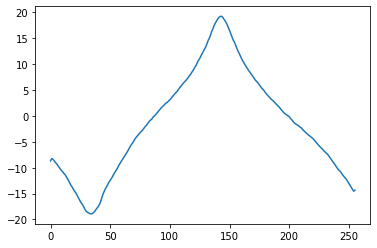

In [55]:
run_flag[0] = True
output_data = {'measured_power':[], 'level':[]}
measured_power = []
level = []

#Reset SLM   
screen_data = window.getBuffer()
screen_data[...] = 0 
window.update()
sleep(1)

process1 = Thread(target=read_ref, args=[powers, run_flag], daemon = True)
process2 = Thread(target=read_signal, args=[powers, run_flag], daemon = True )
#process3 = Thread(target=GammaCurveRoutine, daemon = False )

print('Start power meter threads')
process1.start()    
process2.start() 
#process3.start() 

#print('Joint the process')
#process1.join()    
#process2.join()
#process3.join()
print('Launch Main thread')
sleep(1)
GammaCurveRoutine()
run_flag[0] = False #This will make sure the power meter threads are killed
print('Gamma Curve Done!')

OUT = output_data['measured_power']
l = output_data['level']
plot(l,OUT)
Ext_Ratio = array(OUT).max() - array(OUT).min()
print('Extintion Ratio = ', Ext_Ratio, ' dB')

# Measure SLM gamma curve MultiThreading  (differential)

In [167]:
from IPython.display import clear_output
from systemutils import tcolor
import time
from threading import Thread

#Power Meter Variables
power_offset = 0
powers = [{}]*2 #We store the read powers in the power meter read thread here so we can access from everwhere (GLOBAL VARIABLE)

#Terminate the threads flags
flag = True
run_flag = [1]
run_flag[0] = flag

#Gamma curve variables
gray_level = 0
side = ['left','right'][1]
scan = arange(0,256,1)

output_data = {'measured_PH':[],'measured_PV':[],'measured_Ptotal':[],'measured_Pdiff':[], 'level':[]}
measured_power = []
measured_PH = []
measured_PV = []
measured_Pdiff = []
measured_Ptotal = []
level = []

cnt = zeros(2) #Check number of measurements in both (ref and signal threads)

def read_ref(buffer, flag):
    while flag[0]:
        PM1.read_power_multi_threaded(buffer)
        #cnt[0] = cnt[0] + 1 
        
def read_signal(buffer, flag):
    while run_flag[0]:
        PM2.read_power_multi_threaded(buffer)
        #cnt[1] = cnt[1] + 1
        
def GammaCurveRoutine():
    
    for gray_level in scan:
    
        if side is 'right':
            screen_data[:,1920//2:-1,0] = gray_level # right-side piston
        elif side is 'left':
            screen_data[:,0:1920//2,0] = gray_level # left-side piston

        window.update()
        time.sleep(0.4)  

        clear_output(wait = True)
        
        #Read powers
        p1 = powers[0] #V
        p2 = powers[1] #H
        
        p1W = 10**(p1/10)
        p2W = 10**(p2/10)
        
        differential = abs(p1 - p2)
        total = 10*log10(p1W + p2W)

        #Print Stats
        print(tcolor.RED + 'Powermeter 1: ' + tcolor.END + tcolor.BLUE + f"{p1:0.4f} " + unit +"\n\n" + tcolor.END\
            + tcolor.RED + 'Powermeter 2: ' + tcolor.END + tcolor.BLUE + f"{p2:0.4f} " + unit + "\n\n" + tcolor.END\
            + tcolor.RED + 'Total power: ' + tcolor.END + tcolor.BLUE + f"{total:0.4f} " + unit +"\n\n"+ tcolor.END\
            + tcolor.RED + 'Differential power: ' + tcolor.END + tcolor.BLUE + f"{differential:0.4f} " + unit + tcolor.END)
        
        #Save data
        output_data['measured_PH'].append( p2 )
        output_data['measured_PV'].append( p1 )
        output_data['measured_Ptotal'].append( total )
        output_data['measured_Pdiff'].append( differential )        
        output_data['level'].append(gray_level) 
        

Powermeter 1: -29.3753 dBm

Powermeter 2: -38.8256 dBm

Total power: -28.9084 dBm

Differential power: 9.4503 dBm
Gamma Curve Done!
Extintion Ratio =  20.991851800000003  dB


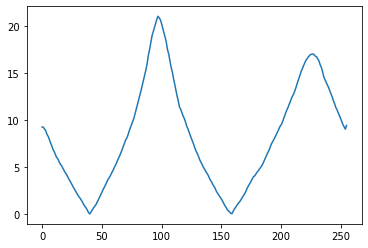

In [168]:
run_flag[0] = True


#Reset SLM   
screen_data = window.getBuffer()
screen_data[...] = 0 
window.update()
sleep(1)

process1 = Thread(target=read_ref, args=[powers, run_flag], daemon = True)
process2 = Thread(target=read_signal, args=[powers, run_flag], daemon = True )

print('Start power meter threads')
process1.start()    
process2.start() 

print('Launch Main thread')
sleep(1)
GammaCurveRoutine()
run_flag[0] = False #This will make sure the power meter threads are killed
print('Gamma Curve Done!')

OUT = output_data['measured_Pdiff']
l = output_data['level']
plot(l,OUT)
Ext_Ratio = array(OUT).max() - array(OUT).min()
print('Extintion Ratio = ', Ext_Ratio, ' dB')

# Measure SLM gamma curve MultiThreading  (differential with REF)

In [21]:
from IPython.display import clear_output
from systemutils import tcolor
import time
from threading import Thread

#Power Meter Variables
power_offset = 0
powers = [{}]*3 #We store the read powers in the power meter read thread here so we can access from everwhere (GLOBAL VARIABLE)

#Terminate the threads flags
flag = True
run_flag = [1]
run_flag[0] = flag

#Gamma curve variables
gray_level = 0
side = ['left','right'][1]
scan = arange(0,256,1) 

output_data = {'measured_PH':[],'measured_PV':[],'measured_Ptotal':[],'measured_Pdiff':[], 'level':[]}
measured_power = []
measured_PH = []
measured_PV = []
measured_Pdiff = []
measured_Ptotal = []
level = []

cnt = zeros(2) #Check number of measurements in both (ref and signal threads)

def read_signal1(buffer, flag):
    while flag[0]:
        PM1.read_power_multi_threaded(buffer)
        #cnt[0] = cnt[0] + 1 
        
def read_signal2(buffer, flag):
    while flag[0]:
        PM2.read_power_multi_threaded(buffer)
        #cnt[1] = cnt[1] + 1
        
def read_ref(buffer, flag):
    while flag[0]:
        PM_ref.read_power_multi_threaded(buffer)
        
def GammaCurveRoutine():
    
    for gray_level in scan:
    
        if side is 'right':
            screen_data[:,1920//2:-1,0] = gray_level # right-side piston
        elif side is 'left':
            screen_data[:,0:1920//2,0] = gray_level # left-side piston

        window.update()
        time.sleep(0.3)  

        clear_output(wait = True)
        
        #Read powers       
        p_ref = powers[2]
        fluctuation = p_ref - ref_power_0
        p1 = powers[0] - fluctuation #V
        p2 = powers[1] - fluctuation #H
        
        p1W = 10**(p1/10)
        p2W = 10**(p2/10)
        
        differential = abs(p1 - p2)
        total = 10*log10(p1W + p2W)

        #Print Stats
        print(tcolor.RED + 'Powermeter 1: ' + tcolor.END + tcolor.BLUE + f"{p1:0.4f} " + unit +"\n\n" + tcolor.END\
            + tcolor.RED + 'Powermeter 2: ' + tcolor.END + tcolor.BLUE + f"{p2:0.4f} " + unit + "\n\n" + tcolor.END\
            + tcolor.RED + 'Total power: ' + tcolor.END + tcolor.BLUE + f"{total:0.4f} " + unit +"\n\n"+ tcolor.END\
            + tcolor.RED + 'Differential power: ' + tcolor.END + tcolor.BLUE + f"{differential:0.4f} " + unit + tcolor.END)
        
        #Save data
        output_data['measured_PH'].append( p2 )
        output_data['measured_PV'].append( p1 )
        output_data['measured_Ptotal'].append( total )
        output_data['measured_Pdiff'].append( differential )        
        output_data['level'].append(gray_level)        

Powermeter 1: -49.7015 dBm

Powermeter 2: -28.7003 dBm

Total power: -28.6660 dBm

Differential power: 21.0011 dBm
Gamma Curve Done!
Extintion Ratio =  37.529075600000006  dB


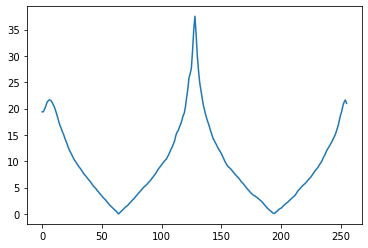

In [22]:
run_flag[0] = True


#Reset SLM   
screen_data = window.getBuffer()
screen_data[...] = 0 
window.update()
sleep(1)

ref_power_0 = PM_ref.read_power_single_threaded()

process1 = Thread(target=read_ref, args=[powers, run_flag], daemon = True)
process2 = Thread(target=read_signal1, args=[powers, run_flag], daemon = True )
process3 = Thread(target=read_signal2, args=[powers, run_flag], daemon = True )

print('Start power meter threads')
process1.start()    
process2.start() 
process3.start() 


print('Launch Main thread')
sleep(1)
GammaCurveRoutine()
run_flag[0] = False #This will make sure the power meter threads are killed
print('Gamma Curve Done!')

OUT = output_data['measured_Pdiff']
l = output_data['level']
plot(l,OUT)
Ext_Ratio = array(OUT).max() - array(OUT).min()
print('Extintion Ratio = ', Ext_Ratio, ' dB')

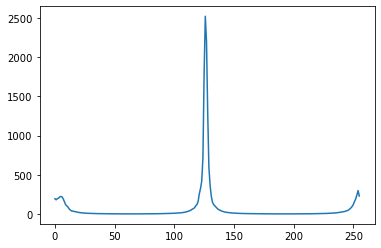

In [16]:
out = array(OUT)
plot(l,10**(out/10))

Extintion Ratio =  0.4121332893733083  dB


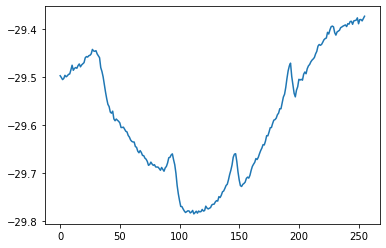

In [24]:
OUT = array(output_data['measured_Ptotal']) 
l = output_data['level']
plot(l,OUT)
Ext_Ratio = array(OUT).max() - array(OUT).min()
print('Extintion Ratio = ', Ext_Ratio, ' dB')

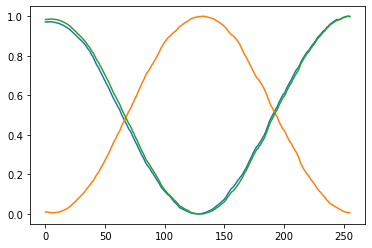

In [23]:
OUT1 = 10**(array(output_data['measured_PH'])/10)
OUT2 = 10**(array(output_data['measured_PV'])/10)

OUT1 = OUT1/OUT1.max()
OUT2 = OUT2/OUT2.max()

OUT = (OUT1-OUT2)
OUT = OUT + abs(OUT.min())
OUT = OUT/ OUT.max()
l = output_data['level']
plot(l,OUT1)
plot(l,OUT2)
plot(l,OUT)

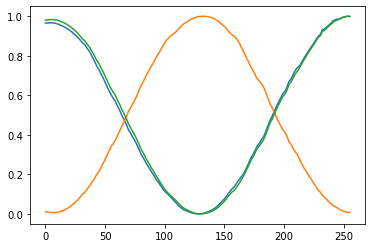

In [20]:
OUT1 = 10**(array(output_data['measured_PH'])/10)
OUT2 = 10**(array(output_data['measured_PV'])/10)

OUT1 = OUT1/OUT1.max()
OUT2 = OUT2/OUT2.max()

OUT = (OUT1-OUT2)
OUT = OUT + abs(OUT.min())
OUT = OUT/ OUT.max()
l = output_data['level']
plot(l,OUT1)
plot(l,OUT2)
plot(l,OUT)

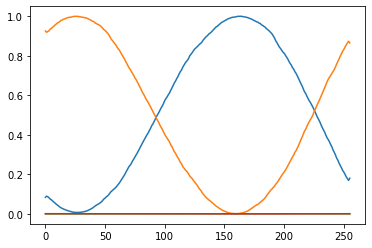

In [42]:
OUT11 = 10**(array(output_data['measured_PH'])/10)
OUT22 = 10**(array(output_data['measured_PV'])/10)
plot(l,OUT1)
plot(l,OUT2)
plot(l,OUT11)
plot(l,OUT22)

The pi shift is at the level 149 out 256
The pi shift is at the level (array([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37],
      dtype=int64),) out 256


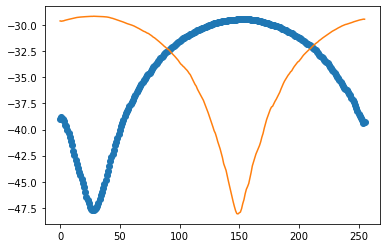

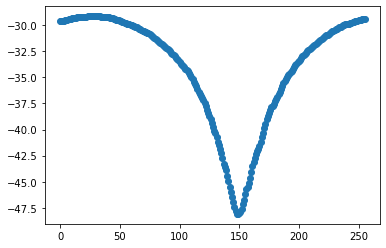

In [132]:
#with ref
OUT1 = output_data['measured_PH']
OUT2 = output_data['measured_PV']

l = output_data['level']
plot(l,OUT1,'o')
plot(l,OUT2)
OUT = array(OUT2)
print('The pi shift is at the level', where(OUT == OUT.min())[0][0], 'out 256')
print('The pi shift is at the level', where(OUT > OUT.max()-0.05), 'out 256') #peak at sample 14 so both pols interfere constructivly at 14 voltage
#+127 samples move it to 141 which is a pi shift producing minimum, so H and V are coming shifted in 14 samples
figure()
plot(OUT,'o')


The pi shift is at the level 141 out 256
The pi shift is at the level (array([251, 252, 253, 254, 255], dtype=int64),) out 256


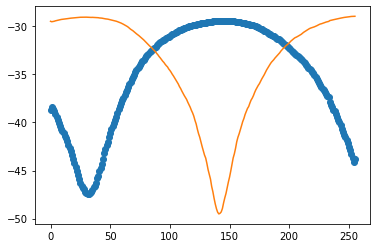

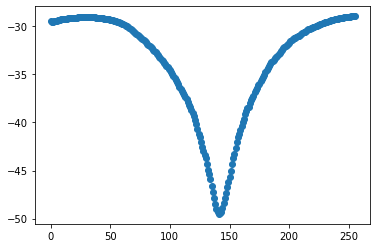

In [119]:
OUT1 = output_data['measured_PH']
OUT2 = output_data['measured_PV']

l = output_data['level']
plot(l,OUT1,'o')
plot(l,OUT2)
OUT = array(OUT2)
print('The pi shift is at the level', where(OUT == OUT.min())[0][0], 'out 256')
print('The pi shift is at the level', where(OUT > OUT.max()-0.05), 'out 256') #peak at sample 14 so both pols interfere constructivly at 14 voltage
#+127 samples move it to 141 which is a pi shift producing minimum, so H and V are coming shifted in 14 samples
figure()
plot(OUT,'o')


The pi shift is at the level 107 out 256
The pi shift is at the level (array([227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239,
       240, 241], dtype=int64),) out 256


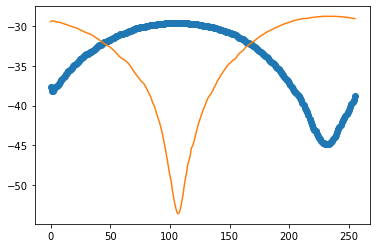

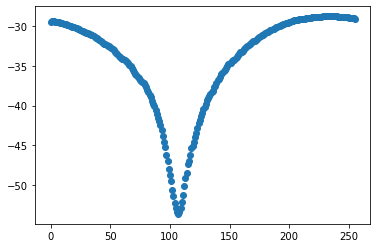

In [34]:
OUT1 = output_data['measured_PH']
OUT2 = output_data['measured_PV']

l = output_data['level']
plot(l,OUT1,'o')
plot(l,OUT2)
OUT = array(OUT2)
print('The pi shift is at the level', where(OUT == OUT.min())[0][0], 'out 256')
print('The pi shift is at the level', where(OUT > OUT.max()-0.05), 'out 256') #peak at sample 14 so both pols interfere constructivly at 14 voltage
#+127 samples move it to 141 which is a pi shift producing minimum, so H and V are coming shifted in 14 samples
figure()
plot(OUT,'o')

The pi shift is at the level 32 out 256
The pi shift is at the level (array([137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
       150, 151, 152], dtype=int64),) out 256


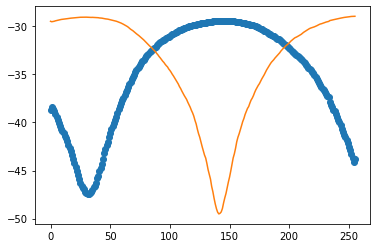

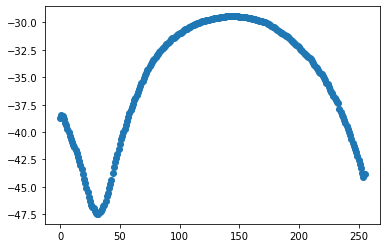

In [124]:
OUT1 = output_data['measured_PH']
OUT2 = output_data['measured_PV']

l = output_data['level']
plot(l,OUT1,'o')
plot(l,OUT2)
OUT = array(OUT1)
print('The pi shift is at the level', where(OUT == OUT.min())[0][0], 'out 256')
print('The pi shift is at the level', where(OUT > OUT.max()-0.05), 'out 256') #peak at sample 14 so both pols interfere constructivly at 14 voltage
#+127 samples move it to 141 which is a pi shift producing minimum, so H and V are coming shifted in 14 samples
figure()
plot(OUT,'o')

The pi shift is at the level 150 out 256
The pi shift is at the level (array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38], dtype=int64),) out 256


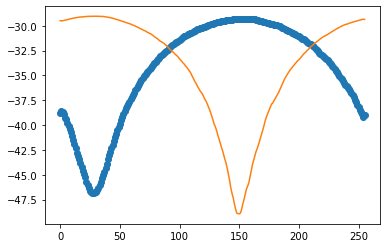

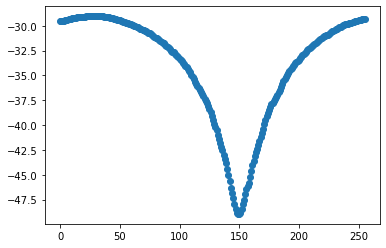

In [186]:
OUT1 = output_data['measured_PH']
OUT2 = output_data['measured_PV']

l = output_data['level']
plot(l,OUT1,'o')
plot(l,OUT2)
OUT = array(OUT2)
print('The pi shift is at the level', where(OUT == OUT.min())[0][0], 'out 256')
print('The pi shift is at the level', where(OUT > OUT.max()-0.05), 'out 256') #peak at sample 14 so both pols interfere constructivly at 14 voltage
#+127 samples move it to 141 which is a pi shift producing minimum, so H and V are coming shifted in 14 samples
figure()
plot(OUT,'o')

# Save all the shit

In [155]:
#Saving stuff

from datetime import datetime

now = datetime.now() 
year = now.strftime("%Y")
month = now.strftime("%m")
day = now.strftime("%d")
time_now = now.strftime("%H_%M_%S")

import pickle
import os

PIK = os.path.join(os.getcwd(),'results', year + '_' + month + '_' + day + '_' + time_now + \
                   '_' + 'Meadowlark_002_1300nm_'+ side +'_side_piston_WITH_REF.pkl')
with open(PIK, "wb") as f:
    pickle.dump(output_data,f, protocol=pickle.HIGHEST_PROTOCOL) 

# Let's try to process the data (DONE IN SLM_Curve_Process_Data...)

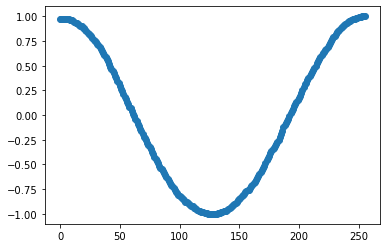

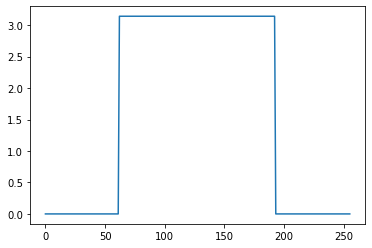

In [10]:
output = 10**((array(OUT) - 30)/10) #W
offset = (output.max() + output.min()) / 2
p = output - offset
p = p / p.max()
plot(p,'-o')
figure()
plot(angle(p))

In [11]:
if p.min() <-1:
    p[where(p == p.min())] = -1
if p.min() >1:
    p[where(p == p.max())] = 1

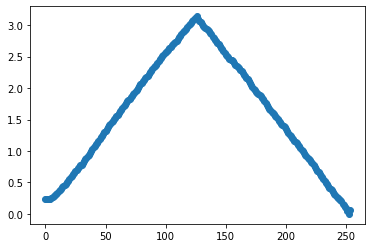

In [12]:
ph = arccos(p[2::])
plot(ph,'o')

# Unwrap the phase

Whole SLM phase drived =  6.112663988959333 rad,  0.9728606893027005  cycles


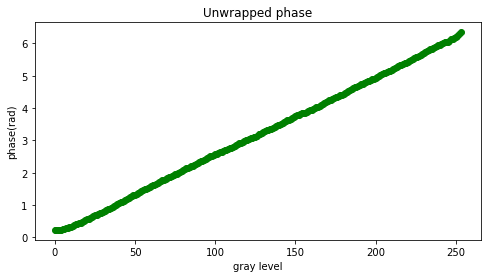

In [13]:
uwph = zeros(ph.shape[0]) #my fresh new unwrapped phase vector
Aph = ph[1::]-ph[0:-1] #Get the gradient 
uwph[0] = ph[0] #Assign first element
for idx,step in enumerate(abs(Aph)):
    uwph[idx+1] = uwph[idx] + step
    
fig,ax = plt.subplots(1,1,figsize=(8,4))
ax.plot(uwph,'o',color='green')
ax.set_title('Unwrapped phase')
ax.set(xlabel = 'gray level', ylabel = r'phase(rad)')
print('Whole SLM phase drived = ', uwph.max() - uwph.min(), 'rad, ', (uwph.max() - uwph.min())/(2*pi), ' cycles')

Whole SLM phase drived =  7.062625999067802 rad,  1.1240518389609766  cycles


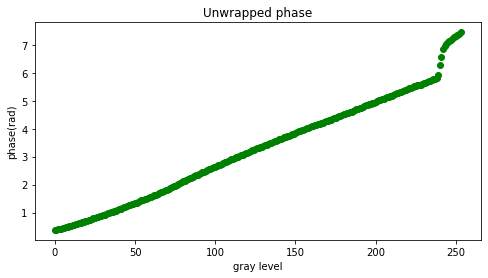

In [133]:
uwph = zeros(ph.shape[0]) #my fresh new unwrapped phase vector
Aph = ph[1::]-ph[0:-1] #Get the gradient 
uwph[0] = ph[0] #Assign first element
for idx,step in enumerate(abs(Aph)):
    uwph[idx+1] = uwph[idx] + step
    
fig,ax = plt.subplots(1,1,figsize=(8,4))
ax.plot(uwph,'o',color='green')
ax.set_title('Unwrapped phase')
ax.set(xlabel = 'gray level', ylabel = r'phase(rad)')
print('Whole SLM phase drived = ', uwph.max() - uwph.min(), 'rad, ', (uwph.max() - uwph.min())/(2*pi), ' cycles')